In [1]:
#Libs
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
# Load Dataset
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [3]:
df = pd.read_csv("diabetes.csv")

In [4]:
# View first records:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# Shape
print("Shape:", df.shape)

Shape: (768, 9)


In [6]:
# Cols
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [7]:
# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [11]:
# Missing Values
(df[['Glucose','BloodPressure','SkinThickness',
     'Insulin','BMI']] == 0).sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [13]:
# Separate Features and Target
# Features (X):
X = df.drop("Outcome", axis=1)

In [14]:
# Target (y):
y = df["Outcome"]

In [15]:
# chekc shapes
print(X.shape)
print(y.shape)

(768, 8)
(768,)


In [16]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
# just to check the shape agian
print(X_train.shape)
print(X_test.shape)

(614, 8)
(154, 8)


In [18]:
# Feature Scaling
scaler = StandardScaler()

In [19]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
print(X_train[:5])

[[-0.52639686 -1.15139792 -3.75268255 -1.32277365 -0.70120553 -4.13525578
  -0.49073479 -1.03594038]
 [ 1.58804586 -0.27664283  0.68034485  0.23350519 -0.70120553 -0.48916881
   2.41502991  1.48710085]
 [-0.82846011  0.56687102 -1.2658623  -0.09071957  0.01344832 -0.42452187
   0.54916055 -0.94893896]
 [-1.13052335  1.2541786  -1.04961706 -1.32277365 -0.70120553 -1.30372015
  -0.63929127  2.79212217]
 [ 0.68185612  0.41066475  0.57222224  1.07648956  2.48460077  1.83812075
  -0.68682934  1.13909516]]


Data Set Summary
*   Total Records: 768
*   Total Features: 8
*   Target Variable: Outcome
*   No NULL values found

Feature Variables
*   Pregnancies
*   Glucose
*   BloodPressure
*   SkinThickness
*   Insulin
*   BMI
*   DiabetesPedigreeFunction
*   Age

Target Variable
*   0 = No Diabetes
*   1 = Diabetes

Preprocessing Performed
*   Train-Test Split (80:20)
*   Feature Scaling using StandardScaler


In [21]:
# PART 2 Building the ANN
# Create Sequential Model
model = Sequential()

In [22]:
# Add Layers
# Input + Hidden Layer 1
model.add(Dense(
    units=16,
    activation='relu',
    input_dim=8
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
# Hidden Layer 2
model.add(Dense(
    units=8,
    activation='relu'
))

In [24]:
# Output Layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

In [25]:
# Complete ANN
model = Sequential([
    Dense(16, activation='relu', input_dim=8),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [26]:
# The modal summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [28]:
# Part 3: Model Training
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.6538 - loss: 0.6826 - val_accuracy: 0.6016 - val_loss: 0.6889
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6945 - loss: 0.6595 - val_accuracy: 0.6504 - val_loss: 0.6692
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7169 - loss: 0.6389 - val_accuracy: 0.6911 - val_loss: 0.6489
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7149 - loss: 0.6187 - val_accuracy: 0.6992 - val_loss: 0.6322
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7189 - loss: 0.5981 - val_accuracy: 0.7154 - val_loss: 0.6167
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7373 - loss: 0.5786 - val_accuracy: 0.6992 - val_loss: 0.6003
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7454 - loss: 0.5613 - val_accuracy: 0.6992 - val_loss: 0.5834
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7536 - loss: 0.5450 - val_accuracy: 0.6992 - val_l

In [30]:
# Training Accuracy
print("Final Training Accuracy:",
      history.history['accuracy'][-1])

Final Training Accuracy: 0.8065173029899597


In [31]:
# Validation Accuracy
print("Final Validation Accuracy:",
      history.history['val_accuracy'][-1])

Final Validation Accuracy: 0.7560975551605225


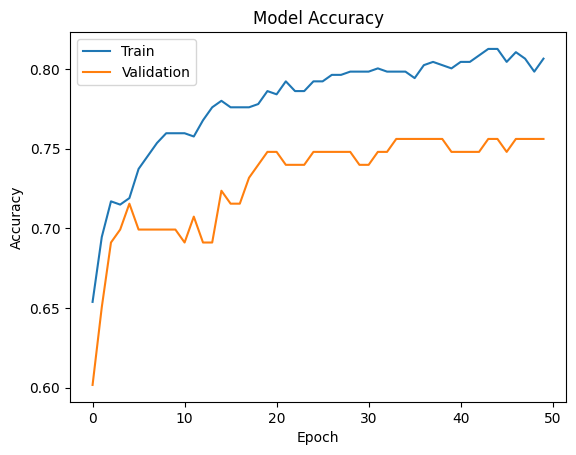

In [32]:
# Plot accuracy
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(['Train','Validation'])

plt.show()

Part 3 Deliverable
Example report:
Training Configuration

*   Epochs: 50
*   Batch Size: 32
*   Optimizer: Adam

Results

*   Training Accuracy: ~80.6%
*   Validation Accuracy: ~75%





In [35]:
# Part 4: Model Evaluation
# Generate Prediction Probabilities
y_prob = model.predict(X_test)
print(y_prob[:10]) # First 10 predictions

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
[[0.2851059 ]
 [0.10495621]
 [0.09044994]
 [0.17206188]
 [0.3297706 ]
 [0.40601158]
 [0.00606315]
 [0.58370715]
 [0.7159198 ]
 [0.65759295]]


In [36]:
# Convert to Class Labels with Threshold = 0.5
y_pred = (y_prob > 0.5).astype(int)


In [37]:
# Accuracy score
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7467532467532467


In [38]:
# Conflusion mtrx
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[78 21]
 [18 37]]


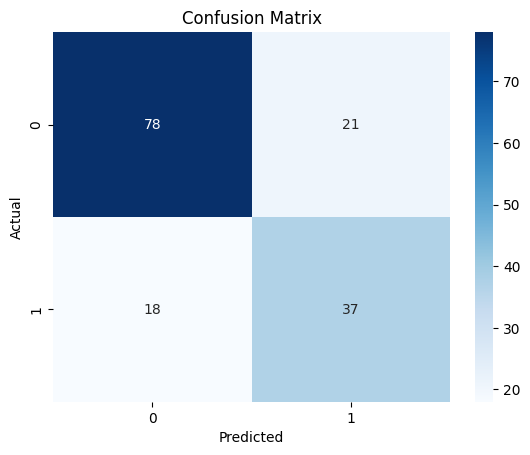

In [39]:
# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()